# 1. Análisis y Exploración de los datos
**Autores:** Eduardo Estefanía Ovejero, David Blasco Tena y Alejandro Jesús Castro García

Origen de los datos: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

## Objetivo
El objetivo del notebook es realizar un proceso de inpsección, limpieza, preprocesado y análisis del dataset.

Se pretende:
- Comprender la estructura del dataset.
- Detectar posibles problemas de calidad de datos.
- Preparar las variables para futuros modelos de ML.
- Extraer conclusiones relevantes a partir del análisis exploratorio.

## 1.1. Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
warnings.filterwarnings(action='ignore')

## 1.2. Carga y Exploración inicial del Dataset

El dataset contien información detallada de los empleados y su estatus de abandono (variable objetivo: **Attrition** con valores Yes/No)

### Variables

#### 1. Varaible Objetivo
- `Attrition`: Indica si el empleado ha dejado la empresa o no. Valores: Yes (Sí, se fue) / No (No, sigue en la empresa).

#### 2. Variables Demográficas y Personales
- `Age`: Edad del empleado en años.

- `Gender`: Género del empleado (Male / Female).
- `MaritalStatus`: Estado civil (Single, Married, Divorced).  
- `Education`: Nivel educativo alcanzado. Es un número del 1 al 5 (1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor').  
- `EducationField`: Rama de estudios del empleado (Ej: Life Sciences, Medical, Marketing, Technical Degree...).  
- `DistanceFromHome`: Distancia desde la casa al trabajo en millas.

#### 3. Variables Laborales
- `Department`: Departamento en el que trabaja (Research & Development, Sales, Human Resources).

- `JobRole`: Cargo específico (Ej: Sales Executive, Research Scientist, Laboratory Technician...).
- `BusinessTravel`: Frecuencia con la que el empleado viaja por trabajo (Non-Travel, Travel_Rarely, Travel_Frequently).
- `OverTime`: Indica si el empleado hace horas extras regulares (Yes / No).

#### 4. Variables Económicas y Salariales
- `MonthlyIncome`: Salario mensual del empleado.

- `PercentSalaryHike`: Porcentaje de aumento salarial que recibió el año pasado.
- `StockOptionLevel`: Nivel de opciones sobre acciones que tiene el empleado (0: No stock options 1: Basic level of stock options, 2: Medium level of stock options, 3: High level of stock options).
- `DailyRate`, `HourlyRate`, `MonthlyRate`: Diferentes métricas de facturación o coste por empleado (diario, por hora, mensual).

#### 5. Variables Historial Laboral y Antigüedad
- `TotalWorkingYears`: Total de años de experiencia laboral del empleado a lo largo de su vida.

- `NumCompanieasWorked`: Número de empresas en las que ha trabajado antes de IBM.
- `YearsAtCompany`: Años que lleva trabajando en la empresa actual.
- `YearsInCurrentRole`: Años que lleva desempeñando su rol actual.
- `YearsSinceLastPromotion`: Años transcurridos desde su último ascenso.
- `YearsWithCurrManager`: Años que lleva trabajando con su jefe actual.
- `TrainingTimesLastYear`: Número de veces que recibió formación el año anterior.

#### 6. Variables Satisfacción y Desempeño
- `EnvironmentSatisfaction`: Satisfacción con el entorno de trabajo (1: Bajo a 4: Muy Alto).

- `JobSatisfaction`: Satisfacción general con su trabajo (1 a 4).
- `RelationshipSatisfaction`: Satisfacción con sus relaciones interpersonales en el trabajo (1 a 4).
- `JobInvolvement`: Nivel de implicación o compromiso con su trabajo (1 a 4).
- `WorkLifeBalance`: Equilibrio entre la vida personal y laboral (1: Malo a 4: Excelente).
- `PerformanceRating`: Calificación de su desempeño laboral (generalmente 3: Excelente, 4: Sobresaliente).


En primer lugar, cargamos el dataset que usaremos en el proyecto.
Este fichero contiene información sobre empleados. Antes de hacer cualquier tipo de análisis, vamos a comprobar las primeras filas para comprobar que la carga se haya hecho correctamente y entender el tipo de información que tenemos disponible.

In [3]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1.3. Inspección general del dataset

Una vez cargados los datos, es importante hacerle una inspección general para responder preguntas tales como:
- ¿Cuántas filas y columnas tiene el dataset?
- ¿Qué variables contiene?
- ¿Qué tipo de dato tiene cada columna?
- ¿Existen ya indicios de problemas de calidad?

Esta revisión inicial ayuda a orienta el resto del análisis

In [4]:
print("Dimensiones del dataset:", df.shape)

print("\nColumnas del dataset:")
print(df.columns.tolist())

Dimensiones del dataset: (1470, 35)

Columnas del dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Además de conocer el número de variables, es importante revisar el tipo de dato de cada una.
Esto es importante porque algunas operaciones dependen directamente de si una columna es numérica, categórica, booleana, etc.

También, nos interesa conocer si existen valores nulos desde el principio.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 1.4. Resumen estadístico inicial

Después de revisar la estructura general, conviene obtener un resumen estadístico de las variables.

En las variables numéricas, este resumen permite ver:
- Medias.
- Desviaciones típicas.
- Mínimos y Máximos.
- Percentiles.

En la variables categóricas, interesa conocer:
- Número de valores distintos.
- categoría  más frecuente.
- Frecuencia de dicha categoría.

Esto sirve para identificar distribuciones extrañas, valores atípicos o columnas con muy poca variabilidad.

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## 1.5. Función de resumen del dataset

Para mejorar la trazabilidad del análisis, se define una función que reúne en un solo punto varias comprobaciones del dataset:
- Dimensiones
- Tipos de datos
- Valores nulos
- Duplicados

Esto permite reutilizar el resumen rápidamente y documentar el proceso.

In [8]:
def resumen_dataset(df):
    """
    Esta funcion muestra un resumen general del dataset para facilitar 
    la inspeccion incial y la trazabilidad del analisis
    
    Parametros:
    - df: DataFrame que queremos resumir
    """
    
    print("RESUMEN DEL DATASET")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")
    
    print("\nTipos de datos:")
    print(df.dtypes.value_counts())
    
    print("\nValores nulos por columna:")
    print(df.isnull().sum().sort_values(ascending=False))
    
    print("\nNumeros de duplicados:", df.duplicated().sum())

resumen_dataset(df)

RESUMEN DEL DATASET
Filas: 1470
Columnas: 35

Tipos de datos:
int64     26
object     9
Name: count, dtype: int64

Valores nulos por columna:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears 

## 1.6. Análisis de calidad de datos

Antes de analizar patrones o relaciones entre variables, debemos comparar si el dataset presenta problemas de calidad.

En esta seccion revisamos:
- Valores nulos.
- Registros duplicados.
- Variables constantes.
- Consistencia general de la columna.

In [9]:
nulos = df.isnull().sum()

# Mostramos solo las columnas que tengan al menos un valor nul
nulos[nulos > 0]

Series([], dtype: int64)

In [10]:
# Porcentaje de valores nulos por columna
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Age                         0.0
Attrition                   0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtC

### Observación de valores nulos.
En este dataset no se esperaban grandes problemas de valores faltantes.
Efectivamente no aparecen nulos, por lo que esto indica que el conjunto de datos tiene una buena calidad inicial desde el punto de vista de completitud.

Aun así, esta comprobación era obligatoria porque hay proyectos en los que los valores nulos condicionan el preprocesado.

In [11]:
# Comprobamos filas duplicadas
df.duplicated().sum()

np.int64(0)

In [12]:
# inspeccionar manualmente las duplicadas
df[df.duplicated()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


### Observaciónn sobre duplicados
Como no existen valores duplicados, no es necesario actuar en este punto.
Si hubieran aparecido, habría sido necesario valorar si se trata de errores reales o de observaciones repetidas de forma justificada.

En general, si un duplicado no aporta información nueva, conviene eliminarlo para evitar que cierta combinaciones de valores tengan un peso mayor.

## 1.7. Identificación de variables con baja o nula variabilidad

Una variable constante, es decir, una variable que tiene el mismo valor en todos los registros, no aporta capacidad explicativa al análisis ni al modelo.

Por esto, en esta seccion identificaremos las columnas que representan un único valor distinto y valoramos su eliminación.

In [13]:
unicos = pd.DataFrame({
    "columna": df.columns,
    "n_unicos": [df[col].nunique() for col in df.columns]
}).sort_values(by="n_unicos")

unicos

,columna,n_unicos
8,EmployeeCount,1
21,Over18,1
26,StandardHours,1
1,Attrition,2
22,OverTime,2
24,PerformanceRating,2
11,Gender,2
2,BusinessTravel,3
4,Department,3
17,MaritalStatus,3


In [14]:
columnas_constantes = [col for col in df.columns if df[col].nunique() == 1]

print("Columnas constantes detectadas:")
print(columnas_constantes)

Columnas constantes detectadas:
['EmployeeCount', 'Over18', 'StandardHours']


In [15]:
df[columnas_constantes].head()

,EmployeeCount,Over18,StandardHours
0,1,Y,80
1,1,Y,80
2,1,Y,80
3,1,Y,80
4,1,Y,80


### Decisión sobre variables constantes

Las variables constantes no ayudan a distinguir un empleado de otros, por lo que no resultan útiles para el análisis ni para el modelado.

Por ello, se eliminan del dataset en esta fase.

In [16]:
df = df.drop(columns=columnas_constantes)

print("Nuevas dimensiones del dataset:", df.shape)

Nuevas dimensiones del dataset: (1470, 32)


### Decisión sobre variable irrelevante
Las variables de identificación no ayudan a distinguir un empleado de otros, por lo que no resultan útiles para el análisis ni para el modelado.

Es solo el ID del empleado. No sirve para predecir nada.

In [17]:
df = df.drop(columns='EmployeeNumber')

print("Nuevas dimensiones del dataset:", df.shape)

Nuevas dimensiones del dataset: (1470, 31)


## 1.8. Identificación de variables categóricas y numéricas

Para analizar el dataset correctamente, conviene separar las variables según su tipo:
- **Categóricas**: expresan categorías o etiquetas.
- **Numéricas**: representan cantidades o medidas.

In [18]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

num_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Variables categoricas:")
print(cat_cols)

print("\nVariables numéricas:")
print(num_cols)

Variables categoricas:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Variables numéricas:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 1.9. Revisión de las categorías de las variables categóricas

Antes de representar las variables categóricas, conviene revisar sus valores posibles.
Esto permite detectar problemas como:
- Categoría duplicada por diferencias de escritura.
- Espacios en blanco.
- Mayúsculas / minúsculas inconsistentes.
- Etiquetas extrañas.

In [19]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- Attrition ---
['Yes' 'No']

--- BusinessTravel ---
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

--- Department ---
['Sales' 'Research & Development' 'Human Resources']

--- EducationField ---
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

--- Gender ---
['Female' 'Male']

--- JobRole ---
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

--- MaritalStatus ---
['Single' 'Married' 'Divorced']

--- OverTime ---
['Yes' 'No']


### Observación sobre variables categóricas

Tras revisar las categorías, se comprueba si existen inconsistencias de formato.
Como los valores eran coherentes y no aparecían etiquetas repetidas, no es necesario hacer una limpieza adicional.

También es de notar que las variables categóricas pueden tener orden, por lo que tendremos: 
- Categóricas Nominales.
- Categóricas Ordinales.

### Variables Categóricas Nominales
Variables sin orden inherente entre categorías:
- **Department**: Human Resources | Research & Development | Sales
- **Education Field**: Human Resources | Life Sciences | Marketing | Medical | Technical Degree | Other
- **Gender**: Female | Male
- **Job Role**: Healthcare Representative | Human Resources | Laboratory Technician | Manager | Manufacturing Director | Research Director | Research Scientist | Sales Executive | Sales Representative
- **Marital Status**: Divorced | Married | Single
- **OverTime** (Binaria): No | Yes
- **Attrition** (Binaria / Variable Objetivo): No | Yes

### Variables Ordinales
Variables categóricas con orden lógico entre categorías (Ordinales):
- **Education**: Below College (1) < College (2) < Bachelor (3) < Master (4) < Doctor (5)
- **Environment Satisfaction**: Low (1) < Medium (2) < High (3) < Very High (4)
- **Job Involvement**: Low (1) < Medium (2) < High (3) < Very High (4)
- **Job Level**: Entry Level (1) < Mid Level (2) < Senior Level (3) < Manager (4) < Executive (5)
- **Job Satisfaction**: Low (1) < Medium (2) < High (3) < Very High (4)
- **Performance Rating**: Excellent (3) < Outstanding (4)
- **Relationship Satisfaction**: Low (1) < Medium (2) < High (3) < Very High (4)
- **Work Life Balance**: Bad (1) < Good (2) < Better (3) < Best (4)
- **Stock Option Level**: None (0) < Low (1) < Medium (2) < High (3)
- **Business Travel**: Non-Travel < Travel_Rarely < Travel_Frequently

### Solución
- **Variables categóricas nominales** → **One-Hot Encoding**
  - Crea una columna binaria (0/1) por cada categoría
  - Elimina una categoría para evitar multicolinealidad (drop='first')
  - Ejemplo: Gender → Gender_Male (1 si Male, 0 si Female)
  
- **Variables ordinales** → **Ordinal Encoding**
  - Asigna números respetando el orden lógico
  - Ejemplo: Education Level → Below College=0, College=1, Bachelor=2, Master=3, Doctor=4  

En este dataset las variables ordinales ya vienen codifcadas por lo que no tendremos que hacer nada excepto **Business Travel** que si hay que codificarla.

## 1.10. Revisión de las variables numéricas
Antes de representar las variables numéricas, conviene revisar su distribución y estadísticos básicos (mínimo, máximo, media, etc.).
Esto permite detectar problemas como:
- Valores atípicos (outliers) extremos que puedan distorsionar el modelo.
- Valores ilógicos para el contexto (ej. edades negativas o salarios a cero).
- Valores nulos encubiertos (ej. el uso de -999 o 9999 para rellenar huecos vacíos).
- Errores en el tipo de dato (números guardados accidentalmente como texto).

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


### Conclusiones sobre la Detección de Valores Atípicos (Outliers)

Tras analizar los estadísticos descriptivos (media, mínimos, máximos), se concluye:

1. **Ausencia de errores lógicos:** No se detectan valores imposibles, como salarios negativos, edades irreales (el rango es de 18 a 60 años) o distancias negativas.
2. **Naturaleza de los Outliers:** Aunque existen valores atípicos matemáticos (especialmente en `MonthlyIncome` y años de experiencia), estos **no son errores de captura**, sino que representan legítimamente a los perfiles directivos y de mayor *seniority* de la empresa. 
3. **Decisión de Tratamiento:** Se ha decidido **NO eliminar ni transformar estos valores atípicos**. En el contexto de retención de talento, el comportamiento de los empleados con salarios más altos es información vital para el modelo de Regresión Logística, ya que ayuda a establecer que a mayor salario, la probabilidad de fuga disminuye drásticamente.

## 1.11. Representación de las variables categóricas

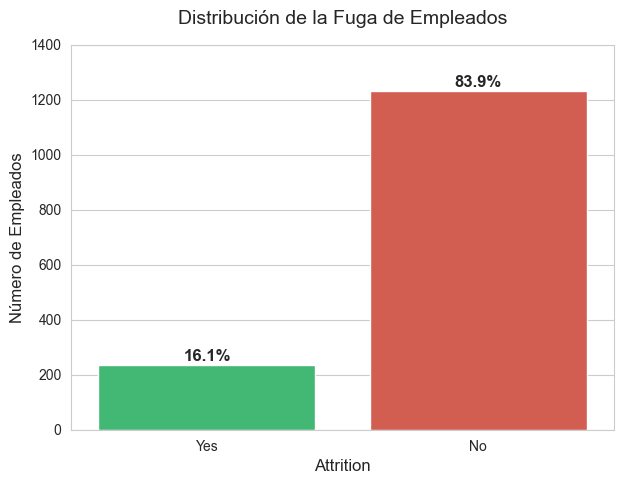

In [21]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x='Attrition', data=df, palette=['#2ecc71', '#e74c3c'])

plt.title('Distribución de la Fuga de Empleados', fontsize=14, pad=15)
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Número de Empleados', fontsize=12)

# Añadir los porcentajes encima de cada barra
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 15
    ax.annotate(porcentaje, (x, y), ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, 1400) # Ajustar el límite Y para que quepa bien el texto
plt.show()

Observamos un claro desbalanceo de clases en nuestro dataset. Aproximadamente el 84% de los empleados permanecen en la empresa, frente a un 16% que la abandonan.  

Acción a tomar: Debido a este desbalanceo, durante la fase de modelado la métrica de Exactitud (Accuracy) será engañosa (un modelo que siempre diga "No" acertaría el 84% de las veces sin aprender nada). Por ello, será crucial evaluar nuestro modelo de Regresión Logística utilizando la Matriz de Confusión y prestando especial atención a la Sensibilidad (Recall) de la clase "Yes".

## 1.12. Representación de las variables numéricas

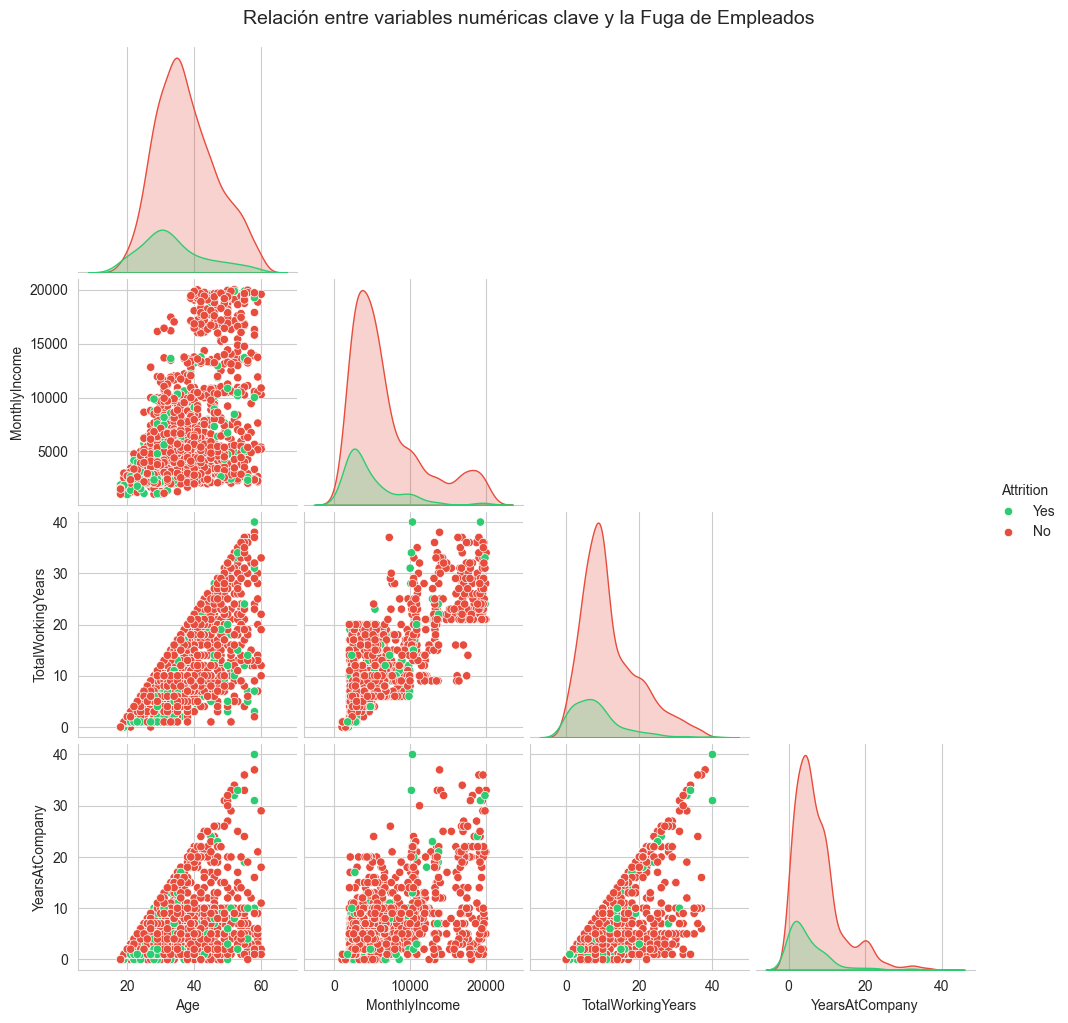

In [22]:
# Seleccionamos un subconjunto de variables numéricas muy relevantes
variables_clave = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Attrition']
df_subset = df[variables_clave]

# Creamos el pairplot coloreando por la variable objetivo (Attrition)
sns.pairplot(df_subset, hue='Attrition', palette=['#2ecc71', '#e74c3c'], corner=True)
plt.suptitle('Relación entre variables numéricas clave y la Fuga de Empleados', y=1.02, fontsize=14)
plt.show()

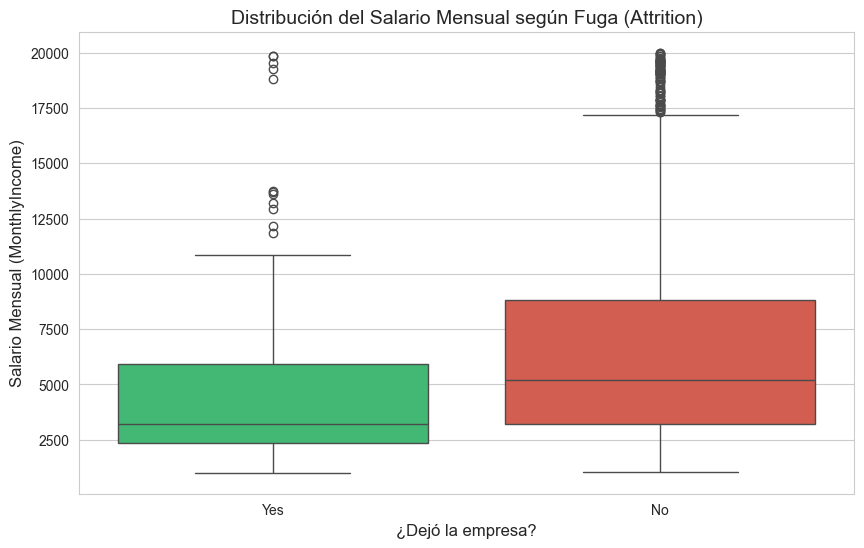

In [23]:
plt.figure(figsize=(10, 6))

# Boxplot de Salario Mensual vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette=['#2ecc71', '#e74c3c'])

plt.title('Distribución del Salario Mensual según Fuga (Attrition)', fontsize=14)
plt.xlabel('¿Dejó la empresa?', fontsize=12)
plt.ylabel('Salario Mensual (MonthlyIncome)', fontsize=12)
plt.show()

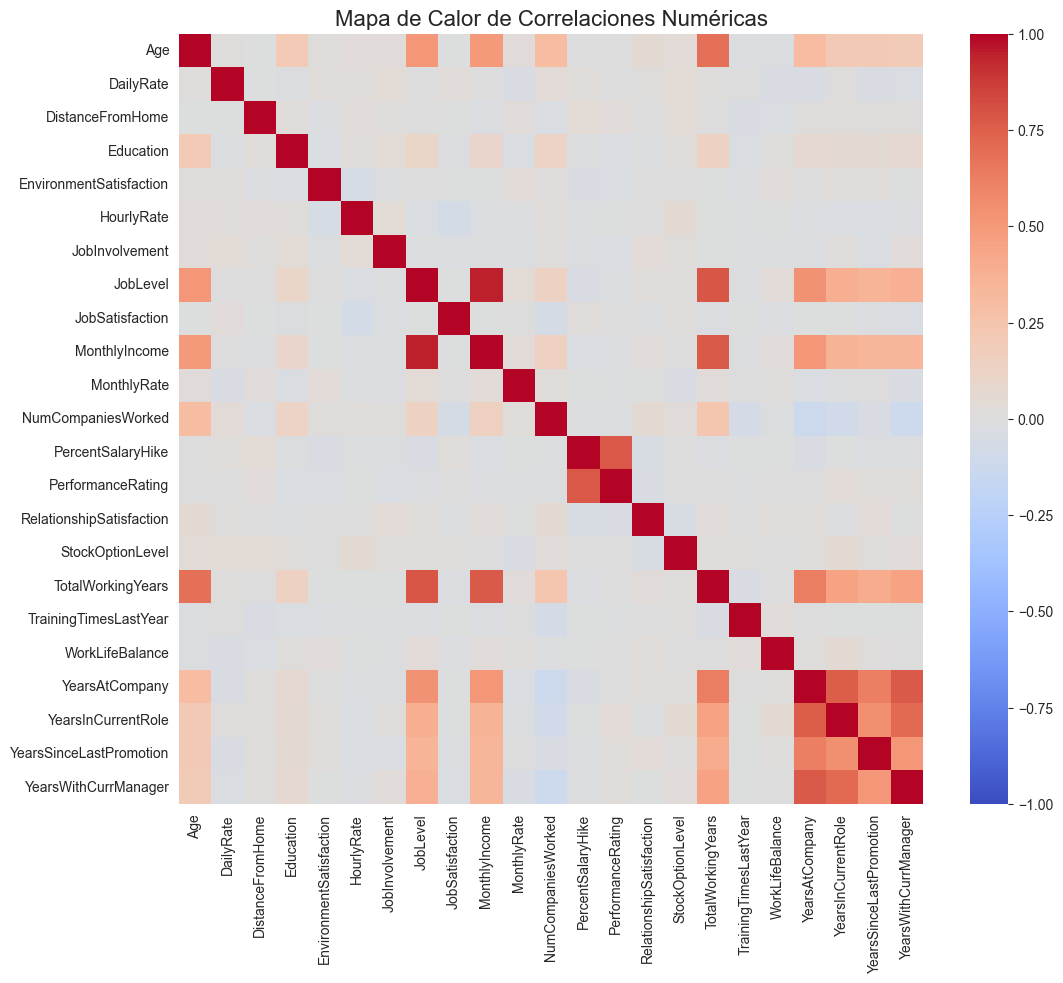

In [24]:
plt.figure(figsize=(12, 10))

# Seleccionamos solo las variables numéricas (descartamos las de texto para este gráfico)
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Calculamos la matriz de correlación
matriz_correlacion = df_numerico.corr()

# Dibujamos el mapa de calor (Heatmap)
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlaciones Numéricas', fontsize=16)
plt.show()

- Salario (Monthly Income): Observando el Boxplot, la mediana del salario de los empleados que abandonan la empresa es visiblemente inferior a la de los que se quedan. Hay una concentración de fugas en los rangos salariales más bajos.
- Valores Atípicos (Outliers): En el boxplot de los que "No" se van, se observan numerosos puntos por encima del bigote superior. Esto indica la presencia de empleados con salarios excepcionalmente altos (directivos), que rara vez abandonan la compañía.
- Correlaciones (Heatmap): En el mapa de calor se observan fuertes correlaciones positivas (cuadrados rojos oscuros) entre variables de antigüedad como YearsAtCompany, YearsInCurrentRole y YearsWithCurrManager. De cara a entrenar nuestro modelo de Regresión Logística, deberemos plantearnos eliminar algunas de estas variables redundantes para evitar problemas de multicolinealidad.

In [25]:
# Guardar el dataset limpio para el siguiente notebook
# IMPORTANTE: index=False evita que Pandas cree una columna extra inútil con los números de fila
df.to_csv('employee_attrition_01.csv', index=False)

print("Dataset limpio guardado correctamente como 'employee_attrition_01.csv'")

Dataset limpio guardado correctamente como 'employee_attrition_01.csv'
